# 1 Target Analysis
analysing the target

<function matplotlib.pyplot.show(close=None, block=None)>

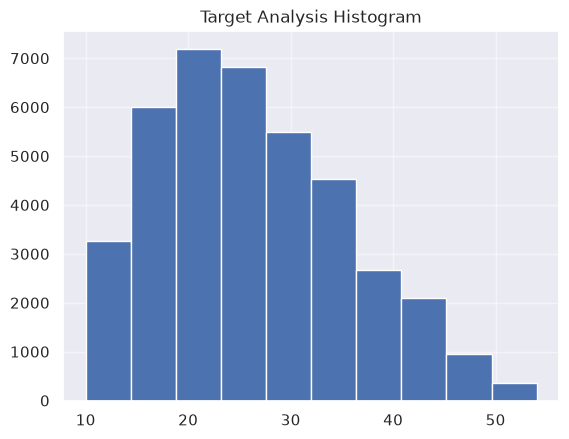

In [89]:
import math
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df = pd.read_csv("../data/processed/clean_data.csv")
target = df["Time_taken(min)"]
plt.title("Target Analysis Histogram")
plt.hist(target)
plt.show

# 2 Numerical variables vs target
analyzing the relationships between numerical features and the target

<function matplotlib.pyplot.show(close=None, block=None)>

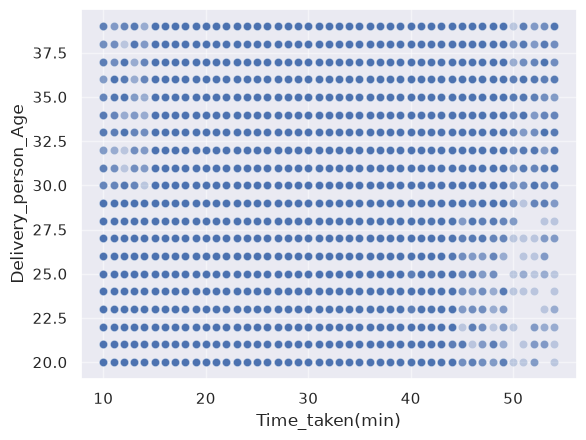

In [90]:
sns.scatterplot(data=df,x='Time_taken(min)',y='Delivery_person_Age',alpha=0.3)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

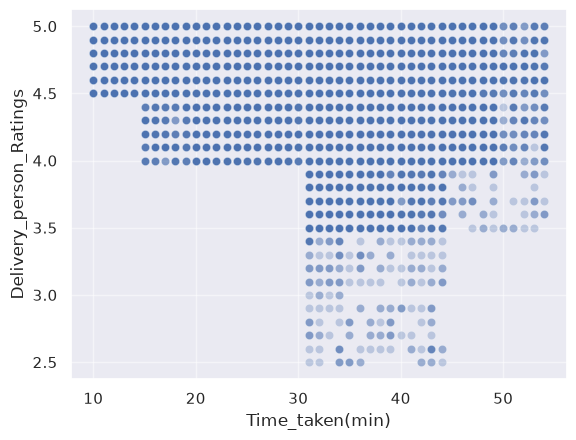

In [91]:
sns.scatterplot(data=df,x='Time_taken(min)',y='Delivery_person_Ratings',alpha=0.3)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

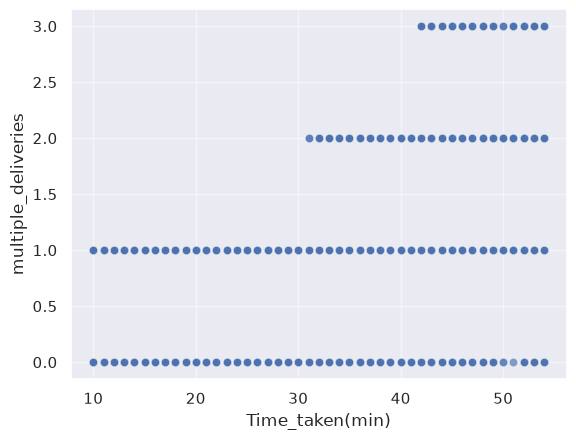

In [92]:
sns.scatterplot(data=df,x='Time_taken(min)',y='multiple_deliveries',alpha=0.3)
plt.show

# 3 Categorical features vs target
analyzing the relationship between categorical features and the target

<function matplotlib.pyplot.show(close=None, block=None)>

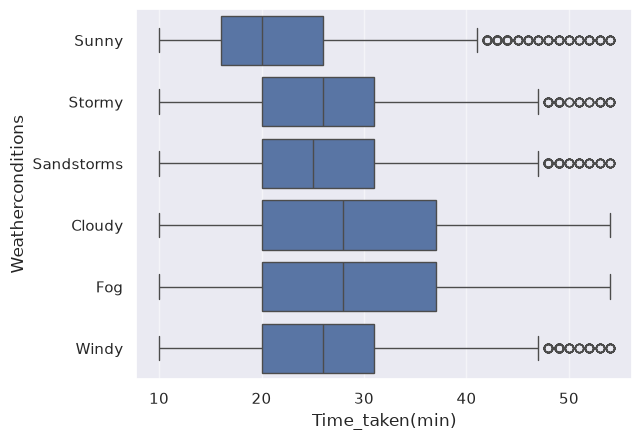

In [93]:
sns.boxplot(data=df,x='Time_taken(min)',y='Weatherconditions')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

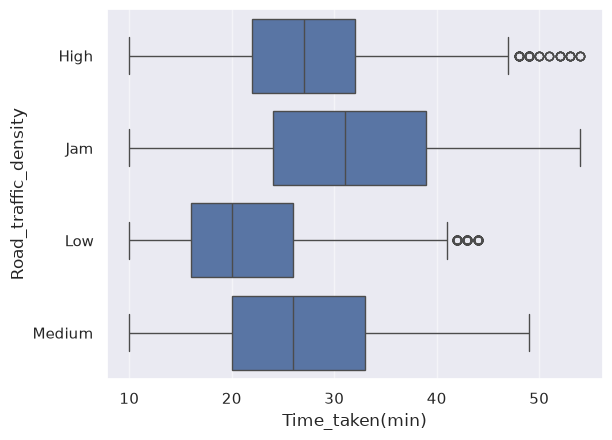

In [94]:
sns.boxplot(data=df,x='Time_taken(min)',y='Road_traffic_density')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

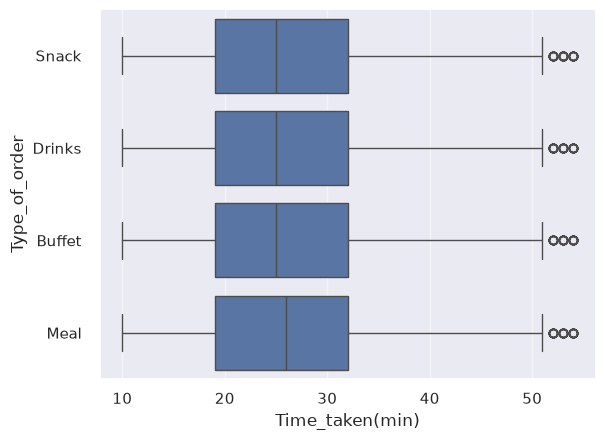

In [95]:
sns.boxplot(data=df,x='Time_taken(min)',y='Type_of_order')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

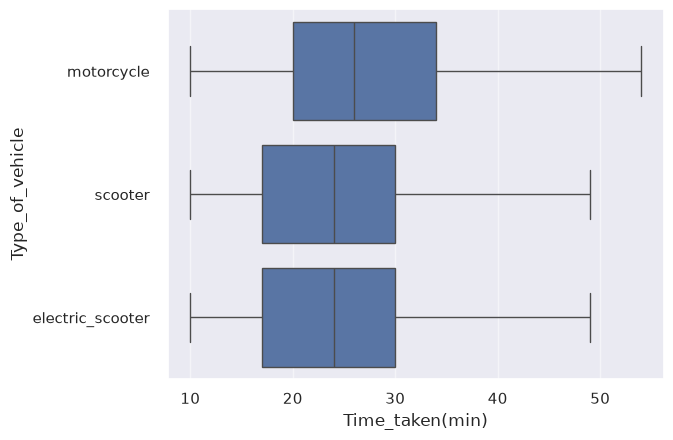

In [96]:
sns.boxplot(data=df,x='Time_taken(min)',y='Type_of_vehicle')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

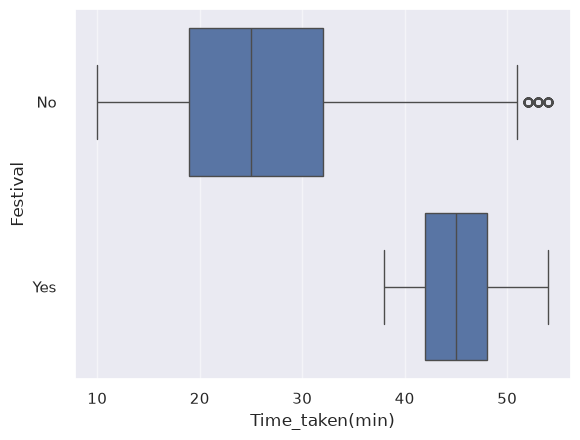

In [97]:
sns.boxplot(data=df,x='Time_taken(min)',y='Festival')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

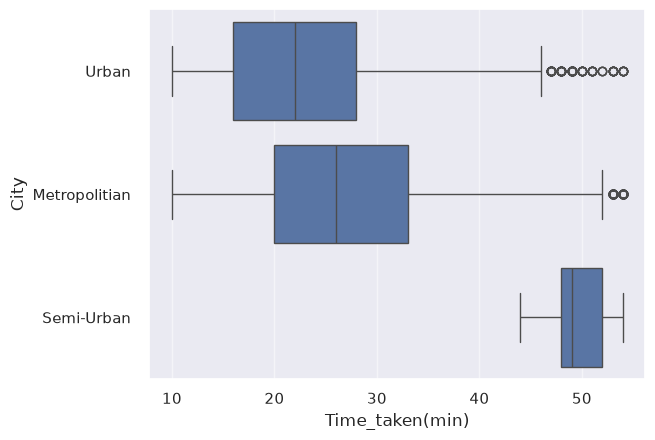

In [98]:
sns.boxplot(data=df,x='Time_taken(min)',y='City')
plt.show

# 4 Correlation matrix
analyzing the relationship between all numerical features

<function matplotlib.pyplot.show(close=None, block=None)>

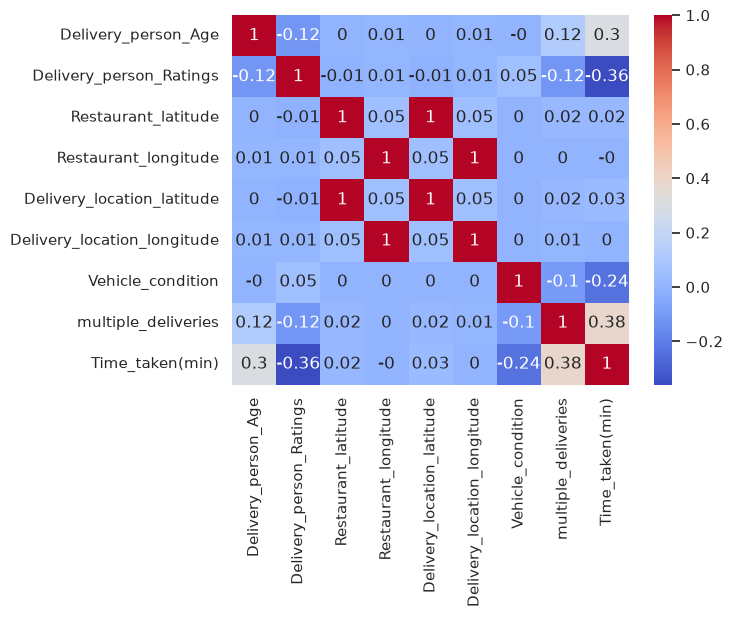

In [99]:
sns.heatmap(
    df.corr(numeric_only=True).round(2),
    annot=True,
    cmap="coolwarm"
)
plt.show

# 5 Feature engineering
Creating new features after observing the features that we have already

In [100]:
def haversin_distance(lat1,lon1,lat2,lon2):
    R = 6371

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = (math.sin(delta_phi/2)**2) + math.cos(phi1) * math.cos(phi2) * (math.sin(delta_lambda/2)**2)
    c = 2 * math.atan2(math.sqrt(a),math.sqrt(1 - a))
    d = R * c

    return d

distances = []

for row in df.itertuples():

    lat1 = row.Restaurant_latitude
    lon1 = row.Restaurant_longitude
    lat2 = row.Delivery_location_latitude
    lon2 = row.Delivery_location_longitude

    distances.append(round(haversin_distance(lat1,lon1,lat2,lon2),1))

df["Distance_km"] = distances.copy()

In [101]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"],format="%d-%m-%Y",errors="coerce")
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"],format="%H:%M:%S",errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"],format="%H:%M:%S",errors="coerce")

differences = ((df["Time_Order_picked"] - df["Time_Orderd"]).dt.total_seconds()/60)%1440

df["Order_picked_hour"] = df["Time_Order_picked"].dt.hour
df["Pickup_delay_minute"] = differences

# 6 Dropping Unnecessary Columns
dropping all unuseful features that won't help in ML

In [104]:
df = df.drop(columns=["ID","Delivery_person_ID","Restaurant_latitude","Restaurant_longitude","Delivery_location_latitude","Delivery_location_longitude","Order_Date","Time_Orderd","Time_Order_picked","Type_of_order"])

df.to_csv("../data/processed/featured.csv",index=False)